In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn as sk
import pandas as pd

# model validation the wrong way
train and validate on same data

In [6]:
wine = sk.datasets.load_wine()
x = wine.data
y = wine.target

model = sk.neighbors.KNeighborsClassifier(n_neighbors=1)

model.fit(x, y)

predictions = model.predict(x)

scores = {
    "accuracy": accuracy_score(y, predictions),
    "precision": sk.metrics.precision_score(y, predictions, average="weighted"),
    "recall": sk.metrics.recall_score(y, predictions, average="weighted"),
    "f1": sk.metrics.f1_score(y, predictions, average="weighted"),
}

scores

{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

In [7]:
wine = sk.datasets.load_wine()
x = wine.data
y = wine.target

X1, X2, y1, y2 = sk.model_selection.train_test_split(x, y, test_size=0.2)

model = sk.neighbors.KNeighborsClassifier(n_neighbors=1)

model.fit(X1, y1)

predictions = model.predict(X2)

scores = {
    "accuracy": accuracy_score(y2, predictions),
    "precision": sk.metrics.precision_score(y2, predictions, average="weighted"),
    "recall": sk.metrics.recall_score(y2, predictions, average="weighted"),
    "f1": sk.metrics.f1_score(y2, predictions, average="weighted"),
}

scores

{'accuracy': 0.7222222222222222,
 'precision': 0.7361111111111112,
 'recall': 0.7222222222222222,
 'f1': 0.7259570494864613}

# model validation via cross-validation
cross validation is using the same data to train and test via different trials.

In [16]:
cv_results = sk.model_selection.cross_validate(
    model,
    x,
    y,
    cv=10,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    n_jobs=-1
 )

scores = {
    "accuracy": float(cv_results["test_accuracy"].mean()),
    "precision_weighted": float(cv_results["test_precision_weighted"].mean()),
    "recall_weighted": float(cv_results["test_recall_weighted"].mean()),
    "f1_weighted": float(cv_results["test_f1_weighted"].mean()),
}
scores

{'accuracy': 0.7480392156862745,
 'precision_weighted': 0.7687142904299767,
 'recall_weighted': 0.7480392156862745,
 'f1_weighted': 0.7394455862812416}

# Selecting the best model
- complicatied vs flexible
- how many samples
- how many features

## the bias-variance tradeoff

## validation curves

Removed 19 outliers


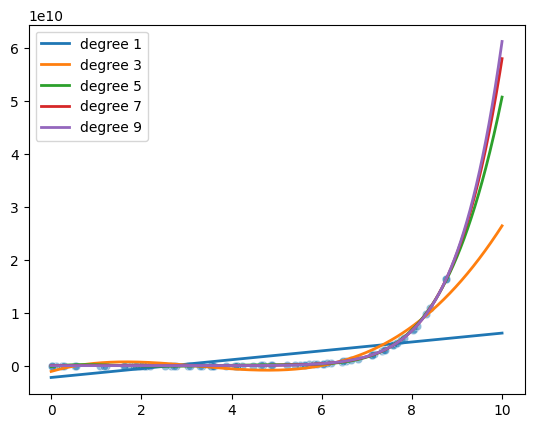

In [105]:
points = 100
error_scale = 1
x = np.random.uniform(0, 10, points).reshape(-1, 1)

true_degree = 10
coefficients = np.random.uniform(-3, 8, true_degree + 1)
y = np.poly1d(coefficients)(x).ravel() + np.random.uniform(0, 1, points) * error_scale

# Find outlier indices in y using the IQR rule
q1, q3 = np.percentile(y, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
indices_to_remove = np.where((y < lower_bound) | (y > upper_bound))[0]

# Drop the same indices from y and x to keep rows aligned
y = np.delete(y, indices_to_remove)
x = np.delete(x, indices_to_remove, axis=0)

print(f"Removed {len(indices_to_remove)} outliers")

sns.scatterplot(x=x.ravel(), y=y, alpha=0.5)

x_test = np.linspace(0, 10, 1000).reshape(-1, 1)

for degree in range(1, 10, 2):
    model = sk.pipeline.make_pipeline(
        sk.preprocessing.PolynomialFeatures(degree=degree),
        sk.linear_model.LinearRegression()
    )
    model.fit(x, y)
    y_pred = model.predict(x_test)
    sns.lineplot(x=x_test.ravel(), y=y_pred, label=f"degree {degree}", linewidth=2)

<Axes: >

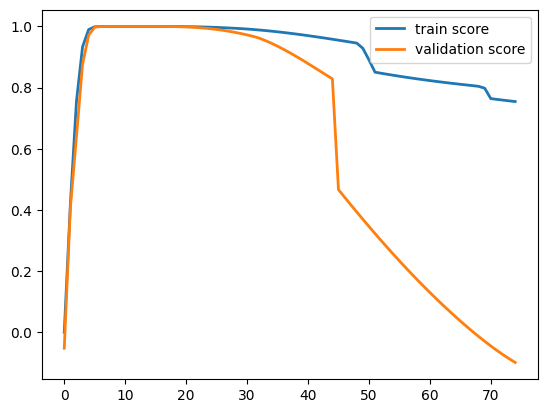

In [113]:
degree = np.arange(75)
train_scores, test_scores = sk.model_selection.validation_curve(
    sk.pipeline.make_pipeline(
        sk.preprocessing.PolynomialFeatures(),
        sk.linear_model.LinearRegression()
    ),
    x, y,
    param_name="polynomialfeatures__degree",
    param_range=degree,
    cv=5
)

sns.lineplot(x=degree, y=np.median(train_scores, 1), label="train score", linewidth=2)
sns.lineplot(x=degree, y=np.median(test_scores, 1), label="validation score", linewidth=2)

# learning curves
